## Jaden Borges
## Roll No: 08
## SE-AIML
## Expt.-6: Classification of Credit Card Default Risk using Support Vector Machine
## Date: 25/02/26

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

## Load Dataset

In [5]:
data = pd.read_csv('credit.csv',skiprows=1)
data = data.sample(5000, random_state=42)

print(data.columns)
data.drop(["ID"], axis=1, inplace=True)
print(data.columns)


Index(['ID', 'LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')
Index(['LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')


In [6]:
print(data.shape)

(5000, 24)


In [7]:
print(data.tail())

       LIMIT_BAL  GENDER  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  \
6778      180000       1          1         2   27      0      0      0   
25284      50000       2          2         2   22      0      0      0   
18355     200000       2          1         2   24     -2     -2     -2   
27684     120000       2          2         2   24      0      0      0   
4110       90000       2          2         1   29      0      0      0   

       PAY_4  PAY_5  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  \
6778       0      0  ...      16908      37319      34978     19000      5000   
25284      0      0  ...      52198      43181      31473      2000      2000   
18355     -2     -2  ...        500       2057      23322      1053         0   
27684      0      0  ...      53216      49194      48487      2000      2600   
4110       0      0  ...       4173       4408       5846      1522      3010   

       PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  default payment

In [8]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 2308 to 4110
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   5000 non-null   int64
 1   GENDER                      5000 non-null   int64
 2   EDUCATION                   5000 non-null   int64
 3   MARRIAGE                    5000 non-null   int64
 4   AGE                         5000 non-null   int64
 5   PAY_0                       5000 non-null   int64
 6   PAY_2                       5000 non-null   int64
 7   PAY_3                       5000 non-null   int64
 8   PAY_4                       5000 non-null   int64
 9   PAY_5                       5000 non-null   int64
 10  PAY_6                       5000 non-null   int64
 11  BILL_AMT1                   5000 non-null   int64
 12  BILL_AMT2                   5000 non-null   int64
 13  BILL_AMT3                   5000 non-null   int64
 14  BILL_AMT4 

In [9]:
print(data.describe())

           LIMIT_BAL       GENDER    EDUCATION     MARRIAGE          AGE  \
count    5000.000000  5000.000000  5000.000000  5000.000000  5000.000000   
mean   167192.000000     1.596600     1.855200     1.550000    35.395000   
std    128399.113714     0.490629     0.778431     0.517642     9.130063   
min     10000.000000     1.000000     0.000000     0.000000    21.000000   
25%     50000.000000     1.000000     1.000000     1.000000    28.000000   
50%    140000.000000     2.000000     2.000000     2.000000    34.000000   
75%    240000.000000     2.000000     2.000000     2.000000    41.000000   
max    800000.000000     2.000000     6.000000     3.000000    72.000000   

             PAY_0        PAY_2        PAY_3        PAY_4        PAY_5  ...  \
count  5000.000000  5000.000000  5000.000000  5000.000000  5000.000000  ...   
mean     -0.011000    -0.137600    -0.157200    -0.221000    -0.269400  ...   
std       1.109381     1.198897     1.219338     1.172874     1.135025  ...   

In [10]:
missing_values = data.isnull().sum()
print(missing_values)

LIMIT_BAL                     0
GENDER                        0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64


In [11]:
y = data['default payment next month']
x = data[['BILL_AMT1','BILL_AMT2']]
print(x.dtypes)
print(x.head())

BILL_AMT1    int64
BILL_AMT2    int64
dtype: object
       BILL_AMT1  BILL_AMT2
2308        8864      10062
22404     136736     125651
23397      70122      69080
25058      20678      18956
2664       94228      47635


## Train Test Split

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [13]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

## Train SVM

In [14]:
models = {
    "Linear SVM": SVC(kernel='linear', C=1, class_weight='balanced'),
    "Polynomial SVM": SVC(kernel='poly', degree=2, C=1, gamma='scale', class_weight='balanced'),
    "RBF SVM": SVC(kernel='rbf', C=5, gamma=0.1, class_weight='balanced'),
}

In [15]:
for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    print(name)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print()

Linear SVM
Confusion Matrix:
 [[ 103 1056]
 [  34  307]]
Accuracy: 0.2733333333333333
Precision: 0.2252384446074835
Recall: 0.9002932551319648
F1 Score: 0.36032863849765256

Polynomial SVM
Confusion Matrix:
 [[  35 1124]
 [   8  333]]
Accuracy: 0.24533333333333332
Precision: 0.22855181880576528
Recall: 0.9765395894428153
F1 Score: 0.3704115684093437

RBF SVM
Confusion Matrix:
 [[560 599]
 [166 175]]
Accuracy: 0.49
Precision: 0.22609819121447028
Recall: 0.5131964809384164
F1 Score: 0.31390134529147984



In [16]:
for name, model in models.items():
    model.fit(x_train, y_train)

    # Training Prediction
    y_train_pred = model.predict(x_train)

    # Testing Prediction
    y_test_pred = model.predict(x_test)

    print(name)

    print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
    print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

    print("Precision:", precision_score(y_test, y_test_pred))
    print("Recall:", recall_score(y_test, y_test_pred))
    print("F1 Score:", f1_score(y_test, y_test_pred))
    print()

Linear SVM
Train Accuracy: 0.2797142857142857
Test Accuracy: 0.2733333333333333
Precision: 0.2252384446074835
Recall: 0.9002932551319648
F1 Score: 0.36032863849765256

Polynomial SVM
Train Accuracy: 0.24114285714285713
Test Accuracy: 0.24533333333333332
Precision: 0.22855181880576528
Recall: 0.9765395894428153
F1 Score: 0.3704115684093437

RBF SVM
Train Accuracy: 0.5017142857142857
Test Accuracy: 0.49
Precision: 0.22609819121447028
Recall: 0.5131964809384164
F1 Score: 0.31390134529147984



## Plotting

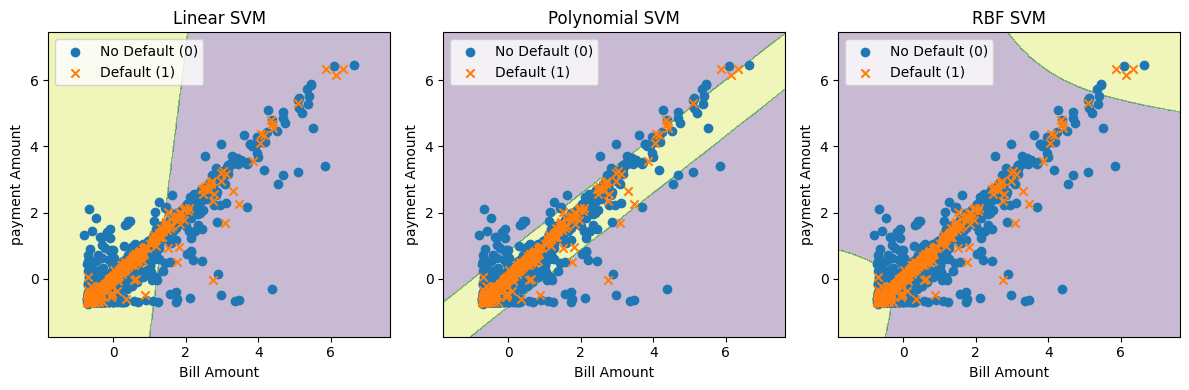

In [17]:
def plot_boundary(model,title):
    h=0.02
    x_min , x_max = x_train[:,0].min()-1,x_train[:,0].max()+1
    y_min , y_max= x_train[:,1].min()-1,x_train[:,1].max()+1
    xx ,yy = np.meshgrid(
        np.arange(x_min ,x_max ,h),
        np.arange(y_min ,y_max ,h)
    )

    Z=model.predict(np.c_[xx.ravel(),yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx,yy,Z,alpha=0.3)

    plt.scatter(x_train[y_train==0,0],
               x_train[y_train==0,1],
               label='No Default (0)',
               marker='o')

    #Class 1
    plt.scatter(x_train[y_train==1,0],
               x_train[y_train==1,1],
               label='Default (1)',
               marker='x')

    plt.legend()
    plt.title(title)
    plt.xlabel("Bill Amount")
    plt.ylabel("payment Amount")

plt.figure(figsize=(12,4))

for i ,(name,model)in enumerate (models.items()):
    plt.subplot(1,3,i+1)
    model.fit(x_train,y_train)
    plot_boundary(model,name)

plt.tight_layout()
plt.show()